<table>
        <td>
        <td><img src="https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/logo_ECI.png" width="400"/></td>
        <td>&nbsp;</td>
        <td>
            <h1 style="font-size:200%;color:blue;text-align:center">    <FONT COLOR="blue"> A. Supervisado </p> Modelos de Regresión  </FONT>         </h1></td>         
        <td>
            <tp><p style="font-size:99%;text-align:center">Machine Learning </p></tp>
            <tp><p style="font-size:115%;text-align:center">Diplomado Ciencia de Datos</p></tp>
            <tp><p style="font-size:115%;text-align:center">Prof. Fabián Sánchez</p></tp>
        </td>
    </tr>
</table>

# <FONT SIZE=5 COLOR="purple"> 1. Introducción </FONT>

**Modelo de regresión:** es el modelo en el que se busca establecer la relación entre un cierto número de características y una variable objetivo continua. Es decir, la relación entre la variable dependiente $y$ y las variables predictoras $x_1, x_2 , \dots , x_n$.

A continuación, definiremos las librerías necesarias para trabajar regresión

In [1]:
# Para gráficos y data.frames
import pandas as pd
import numpy  as np

# librerías para graficar
import plotly.express     as px
import matplotlib.pyplot  as plt
import seaborn            as sns


# Dividir los datos entrenamiento y prueba
from sklearn.model_selection     import train_test_split
from sklearn.feature_selection   import RFE

# Para preprocesamiento: escalador
from sklearn.preprocessing       import StandardScaler

# Modelo de regresión
from sklearn.linear_model        import LinearRegression
from sklearn.svm                 import SVR
from sklearn.neighbors           import KNeighborsRegressor
from sklearn.tree                import DecisionTreeRegressor
from sklearn.ensemble            import RandomForestRegressor

# Métricas
from sklearn                     import metrics
from sklearn.metrics             import mean_squared_error, r2_score, mean_absolute_error

# warnings
import warnings
warnings.filterwarnings('ignore')

# <FONT SIZE=5 COLOR="purple"> 2. Conceptos básicos de Machine Learning: Regresión </FONT>

En está sección revisaremos algunos conceptos básicos de machine learning.

<FONT SIZE=3 COLOR="green"> a. Algoritmos de regresión: </FONT>  técnicas de aprendizaje supervisado para hacer predicciones sobre una variable objetivo $\mathbf{y}$ que es numérica continua, es decir, toma valor en un intervalo.


<center><FONT SIZE=4 COLOR="BLUE">Situación 1: Predicción ventas </FONT></center>

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/ef2f70be5b4059198fa6d856ae1ad0b9802960df/supervisado4.png?raw=true" alt="centered image" width="300" height="150"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>

<center><FONT SIZE=4 COLOR="BLUE">Situación 2: Predicción precio apartamento </FONT></center>

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/34ca9d1b545bc223a6505754189ac5499fdbc560/intro_regresion_1.jpg?raw=true" alt="centered image" width="300" height="150"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>


<FONT SIZE=3 COLOR="green"> b. Variable Objetivo: </FONT> también denominada **variable de respuesta**. En un algoritmo de aprendizaje de máquina supervisado, es la variable que queremos predecir (por lo general, denotada como $\mathbf{y}$).
<br>

<FONT SIZE=3 COLOR="green"> c. Variable(s) Predictora(s): </FONT> también denominada ***features*** o características, son las variables que se usarán para predecir la variable objetivo. Estas se denotan como

$$\mathbf{X}=\{X_1,X_2, \dots, X_n \}$$

<br>

<FONT SIZE=3 COLOR="green"> d. Conjunto de Entrenamiento: </FONT> es el subconjunto de registros que se selecciona para entrenar el modelo. Este conjunto consta de dos partes:

- $X_{train}$ : conjunto de entrenamiento de los predictores o *features*.

- $y_{train}$: conjunto de entrenamiento de la variable objetivo asociada al conjunto $X_{train}$.

El conjunto de entrenamiento se selecciona de manera aleatoria y por lo general se toma el $70\%$ , $75\%$ y $80 \%$.

<br>

<FONT SIZE=3 COLOR="green"> e. Conjunto de Prueba: </FONT>: Es el subconjunto de registros que se selecciona para validar el modelo. Consta de dos partes:

- $X_{test}$ : conjunto de validación de los predictores o *features*.

- $y_{test}$: conjunto de validación de la variable objetivo asociada al conjunto $X_{test}$.

El tamaño de este conjunto es el complemento del conjunto de entrenamiento.

**Nota:** para algoritmos clásicos de machine learning se acostumbra dividir en entrenamiento y prueba. Sin embargo, en algoritmos más complejos que requieren el entrenamiento de mucho parámetros, como es el caso de las redes neuronales, se acostumbra dividir en tres partes: *train* , *validation* and *test*.

<center><FONT SIZE=4 COLOR="BLUE"> Esquema general de modelos supervisados en Machine Learning </FONT></center>

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/209c0394fc9518a5c7331d550d5606bf355c5707/esquema_modelos.jpg?raw=true" alt="centered image" width="500" height="400"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>


<FONT SIZE=4 COLOR="blue"> Algunos modelos de regresión </FONT>

Dentro de la bateria de modelos usados para regresión tenemos

1. Regresión lineal simple.

2. Regresión lineal múltiple

3. knn (k-vecinos más cercanos)

4. Árboles de Decisión

5. SVR: máquina de vectores de soporte para regresión

6. Random Forest


# <FONT SIZE=5 COLOR="purple"> 3. Modelo de Regresión </FONT>

En esta sección revisaremos los modelos de

- Regresión lineal

- k-vecinos más cercanos para regresión

- árboles de decisión para regresión









## <FONT SIZE=4 COLOR="green"> 3.1 Covarianza </FONT>

La covarianza es el valor que refleja en que medida dos variables aleatorias varian de forma conjunta respecto a sus medias.

De acuerdo con lo anterior, la covarianza está dada por la siguiente fórmula

$$Muestra: Cov(X,Y)=S_{xy}=\dfrac{\sum \limits_{i=1}^n (x_i-\overline{x})(y_i-\overline{y})}{n-1}$$

$$Poblacion:COV(X,Y)=\sigma_{XY}=\dfrac{\sum \limits_{i=1}^N (x_i-\mu_x)(y_i-\mu_y)}{N}$$

donde $\overline{x}$ y $\overline{y}$ son las medias de las variables $X$ y $Y$ respectivamente y $n$ es el total de observaciones.

A continuación listaremos algunas propiedades de la covarianza

- $Cov(X,c)=0$, donde $c$ es una constante.

- $Cov(X,X)=Var(X)$, la covarianza de una variable con si misma es la varianza de la variable.

- $Cov(X,Y)=C(Y,X)$, la varianza es simétrica, es decir, no importa el orden en que se coloquen la variables.

- La covarianza mide la fuerza de la relación lineal entre dos variables.

- Una alta covarianza no implica efecto causal.

**Interpretación de la covarianza**

- $Cov(X,Y)>0$ ; las variables $X$ y $Y$ tienden a moverse en la misma dirección.

- $Cov(X,Y)<0$   las variables $X$ y $Y$ tienden a moverse en direcciones opuestas.

- $Cov(X,Y)=0$: las variables $X$ y $Y$ no estan relacionadas linealmente.

## <FONT SIZE=4 COLOR="green"> 3.2 Coeficiente de Correlación </FONT>

El coeficiente de correlación se define como

$$muestra: r_{xy}=\dfrac{S_{xy}}{S_xS_y} \qquad \qquad poblacion : \rho_{xy}=\dfrac{\sigma_{xy}}{\sigma_{x}\sigma_{y}}$$

lo que es equivalente a

$$r_{xy}=\dfrac{\sum \limits_{i=1}^n (x_i-\overline{x})(y_i-\overline{y})}{\left (\sum \limits_{i=1}^n (x_i-\overline{x})^2 \right)^{1/2} \left ( \sum \limits_{i=1}^n (y_i-\overline{y})^2 \right)^{1/2}}$$

Veamos la interpretación de los diferentes valores del coeficiente de correlación de Pearson, teniendo en cuenta que:

$$-1 \leq r_{xy} \leq 1 $$

- Si $r_{xy}=1$, hay una relación positiva perfecta, es decir, indica una dependencia total entre las variables de manera directa. Si una de ellas aumenta, la otra también lo hace en proporción constante. Es decir, la relación es lineal.

- Si $0<r_{x,y}<1$, existe una correlación positiva.

- Si $r_{x,y}=0$, no existe relación lineal. Pero pueden haber otro tipo de relaciones.

- Si $-1<r_{x,y}<0$, existe una correlación negativa.

- Si $r_{x,y}=-1$, existe una correlación negativa perfecta, es decir, indica una dependencia total de manera inversa. Si una variable disminuye la otra aumenta en proporción constante.


<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/da5b836cf8bee14fa8ca4ffa3e53dd97c41136ea/regresi%C3%B3n4.png?raw=true" alt="centered image" width="400" height="400"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>


Algunas propiedades para tener en cuenta del coeficiente de correlación:

- No depende de las unidades de las variables.

- El coefiente de Pearson es acotado

## <FONT SIZE=4 COLOR="green"> 3.3 Modelo de regresión lineal simple </FONT>

Supongamos que tenemos dos variables cuantitativas, que representan en el plano un conjunto de puntos $(x,y)$. En general, estos puntos no tienen porque estar ajustados de forma lineal, es decir, el diagrama de dispersión no tiene porque representar una recta.

Sin embargo, existen situaciones en que los puntos se aproximan o se ajustan en mayor medida a una línea recta. Particualmente cuando el coeficiente de correlación es cercano a 1 o a -1.

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/676fc5569462ef54d082e0a8f9fbf38686efc298/Regresi%C3%B3n/regresion1.png?raw=true" alt="centered image" width="550" height="350"></center>
<br>

La idea es encontrar una recta que se aproxime a los puntos dados

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/676fc5569462ef54d082e0a8f9fbf38686efc298/Regresi%C3%B3n/regresion2.png?raw=true" alt="centered image" width="550" height="300"></center>
<br>

Para hallar la ecuación de la recta que se observa en el gráfico se puede usar:

- Método de los mínimos cuadrados.

- Descenso del gradiente







## <FONT SIZE=4 COLOR="green"> 3.4 Modelo de knn para regresión </FONT>

En lugar de clasificar una muestra, el knn para regresión predice un valor numérico, como sigue:

1. **Identificación de los vecinos más cercanos**: Dado un nuevo punto de datos, el algoritmo busca los **k** puntos más cercanos en el espacio de características (según una medida de distancia como la euclidiana).
   
2. **Cálculo del valor predicho**: El valor de salida para el punto nuevo se calcula promediando los valores de las etiquetas de los **k** vecinos más cercanos. Es decir:
$$   \hat{y} = \frac{1}{k} \sum_{i=1}^{k} y_i $$
   
donde $ y_i $ son las etiquetas de los k-vecinos más cercanos.

3. **Suavizado del resultado**: Como resultado, el valor de salida es continuo, lo que convierte al tree en una técnica válida para regresión.

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/9560be97d66e196d7b0a03cc9fb3d69f1d393ba4/regresion_5.jpg?raw=true" alt="centered image" width="400" height="350"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>

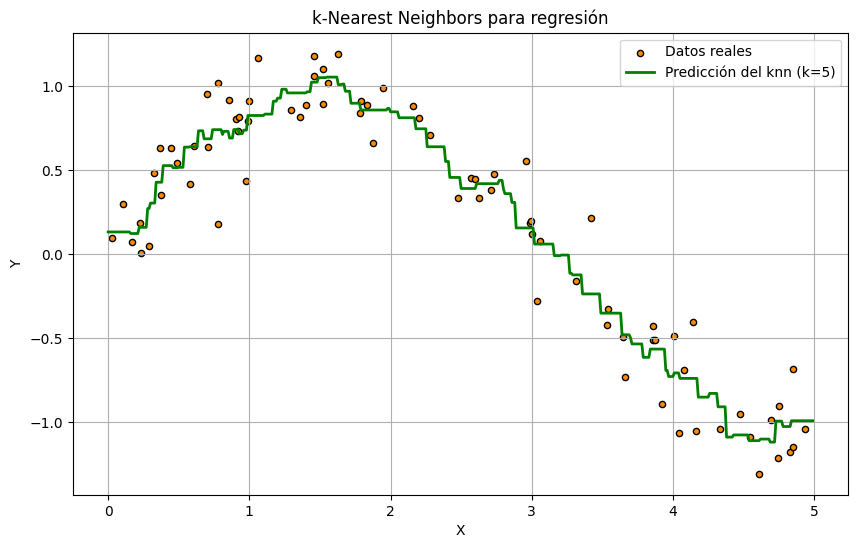

In [2]:
# Generamos datos de ejemplo
np.random.seed(42)
X = np.sort(5 * np.random.rand(80, 1), axis=0)
y = np.sin(X).ravel() + np.random.randn(80) * 0.2

# Creamos un modelo de tree para regresión
knn_regressor = KNeighborsRegressor(n_neighbors=5)
knn_regressor.fit(X, y)

# Predicciones
X_test = np.arange(0.0, 5.0, 0.01)[:, np.newaxis]
y_knn_pred = knn_regressor.predict(X_test)

# Gráfica
plt.figure(figsize=(10, 6))
plt.scatter(X, y, s=20, edgecolor="black", c="darkorange", label="Datos reales")
plt.plot(X_test, y_knn_pred, color="green", label="Predicción del knn (k=5)", linewidth=2)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("k-Nearest Neighbors para regresión")
plt.legend()
plt.grid(True)

plt.show()

## <FONT SIZE=4 COLOR="green"> 3.5 Modelo de Árboles de Decisión para regresión </FONT>

En los árboles de decisión para regresión, el procedimiento también cambia respecto al de clasificación:

1. **División del conjunto de datos**: El árbol se construye dividiendo el conjunto de datos en ramas con base en los valores de las características. Sin embargo, en lugar de buscar divisiones que maximicen la ganancia de información o el índice de Gini (usado en clasificación), en regresión se busca minimizar la **varianza** o el **error cuadrático medio** (MSE, por sus siglas en inglés).

2. **Predicción**: Una vez que el árbol está entrenado, la predicción para un nuevo punto de datos se realiza navegando por el árbol desde la raíz hasta una hoja. El valor en la hoja no es una clase, sino un valor promedio de las etiquetas de los datos que caen en esa hoja.

3. **Criterio de división**: Para cada nodo, el árbol selecciona la característica y el punto de división que minimicen la suma del error cuadrático medio en los subconjuntos hijos.

El modelo final hace una predicción basada en los valores promedio de los datos en los nodos terminales, obteniendo así una predicción numérica.

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/9560be97d66e196d7b0a03cc9fb3d69f1d393ba4/regresion_6.jpg?raw=true" alt="centered image" width="400" height="350"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>

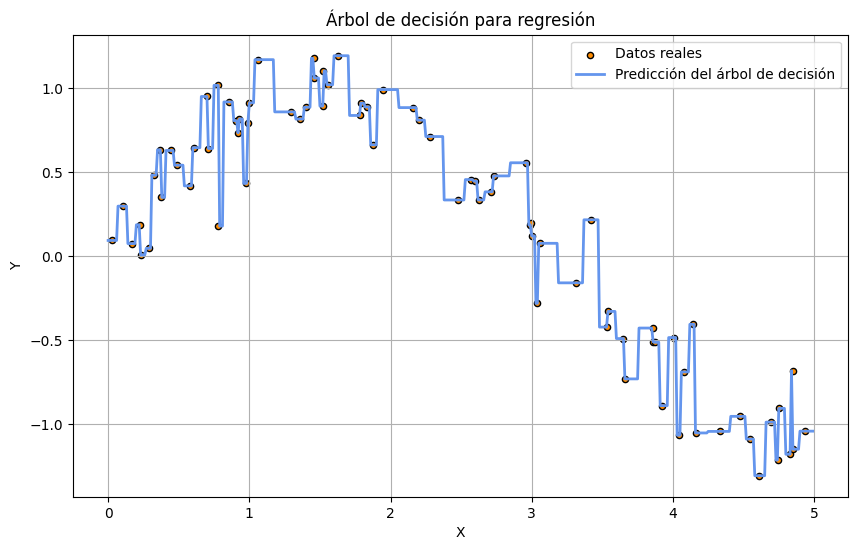

In [ ]:
# Generamos datos de ejemplo
np.random.seed(42)
X = np.sort(5 * np.random.rand(80, 1), axis=0)
y = np.sin(X).ravel() + np.random.randn(80) * 0.2

# Ajustamos un árbol de decisión para regresión
tree_regressor = DecisionTreeRegressor()
tree_regressor.fit(X, y)

# Predicciones
X_test = np.arange(0.0, 5.0, 0.01)[:, np.newaxis]
y_pred = tree_regressor.predict(X_test)

# Gráfica
plt.figure(figsize=(10, 6))
plt.scatter(X, y, s=20, edgecolor="black", c="darkorange", label="Datos reales")
plt.plot(X_test, y_pred, color="cornflowerblue", label="Predicción del árbol de decisión", linewidth=2)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Árbol de decisión para regresión")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# profundidad del arbol tree_regressor.
tree_regressor.get_depth()

In [ ]:
# graficar el árbol completo
from sklearn.tree             import export_graphviz
from graphviz                 import Source

# Revisamos la profundidad y el número de nodos terminales
print(f"Profundidad del árbol: {tree_regressor.get_depth()}")
print(f"Número de nodos terminales: {tree_regressor.get_n_leaves()}")
# Generamos el árbol
dot_data = export_graphviz(tree_regressor,                           # modelo
                           filled=True,)                         # colores del árbol (relleno)
Source(dot_data, format="png")

**Comparación**:
- En **tree para regresión**, la predicción es un promedio de los vecinos cercanos.
- En **árboles de decisión para regresión**, la predicción es el valor promedio de los datos en las hojas del árbol.

# <FONT SIZE=5 COLOR="purple"> 4. Evaluación de un modelo de regresión </FONT>

En esta sección revisaremos la forma en que se evalúa un modelo de regresión.

***MSE : Error cuadrático medio***

Matemáticamente, el $MSE$ se puede calcular como la suma promedio de la diferencia al cuadrado entre el valor real y el valor previsto o estimado representado por el modelo de regresión (línea o plano).

<center><img src="https://github.com/Fabian830348/cursos/blob/60c8c4294b17fa92f33164013afb296294577486/mse.jpg?raw=true" alt="centered image" width="500" height="300"></center>

***$R^2$ coeficiente de determinación***

$R^2$ es la relación entre la regresión de suma de cuadrados (SSR) y la suma de cuadrados total (SST).

$$R^2 = \dfrac{SSR}{SST}= \dfrac{\sum \limits_{i=1}^{n} (\hat{y_i}-\overline{y})^2}{\sum \limits_{i=1}^{n} (y_i - \overline{y})^2}$$

<center><img src="https://github.com/Fabian830348/cursos/blob/f8b630f3ce112dc8d05c828d9b5d3ac328c9544f/Imagen/reg2.png?raw=true" alt="centered image" width="500" height="300"></center>

La regresión de suma de cuadrados (SSR) representa la variación total de todos los valores pronosticados encontrados en la línea o plano de regresión del valor medio de todos los valores de las variables de respuesta. La suma de los cuadrados totales $SST$ representa la variación total de los valores reales del valor medio de todos los valores de las variables de respuesta.

El valor $R^2$ se utiliza para medir la bondad de ajuste o la línea de mejor se ajusta. Cuanto mayor sea el valor de $R^2$, mejor será el modelo de regresión, ya que la mayor parte de la variación de los valores reales a partir del valor medio queda explicada por el modelo de regresión.

**NOTA**

En regresión lineal se recomienda utilizar $R^2$ para evaluar el rendimiento del modelo de los modelos de regresión. Esto se debe principalmente a que $R^2$  captura la fracción de varianza de los valores reales capturados por el modelo de regresión y tiende a brindar una mejor imagen de la calidad del modelo de regresión. Además, los valores de $MSE$ difieren en función de si los valores de la variable de respuesta están escalados o no. Una mejor medida en lugar de MSE es el error cuadrático medio (RMSE) que se ocupa del hecho relacionado con si los valores de la variable de respuesta están escalados o no.

**CONCLUSIONES**

- $MSE$ representa el error residual que no es más que la suma de la diferencia al cuadrado entre los valores reales y los valores previstos/estimados divididos por el número total de registros.

- $R^2$ representa la fracción de varianza capturada por el modelo de regresión.

- La desventaja de usar $MSE$ es que este valor varía en función de si los valores de la variable de respuesta están escalados o no. Si está escalado, el MSE será más bajo que los valores no escalados.

Vamos a cargar las librerías necesarias para el trabajo de los ejemplos de regresión

# <FONT SIZE=5 COLOR="purple"> 5. Ejemplo: Modelo de Regresión (Datos Ventas) </FONT>

**Contexto del problema**

Una empresa dedicada a la comercialización de productos de consumo desea mejorar la planificación de sus estrategias comerciales mediante el uso de técnicas de aprendizaje automático (*Machine Learning*).

Actualmente, la empresa dispone de información histórica relacionada con sus ventas, inversiones en diferentes canales publicitarios (televisión, radio, prensa e internet), precios de los productos, descuentos aplicados, cobertura de distribución y comportamiento estacional del mercado.

El objetivo consiste en desarrollar un modelo predictivo que permita estimar el volumen de ventas a partir de estas variables, identificando patrones y relaciones que contribuyan a mejorar la toma de decisiones comerciales.

Este problema corresponde a una tarea de **aprendizaje supervisado de tipo regresión**, debido a que la variable que se desea predecir es numérica y continua.

**Objetivo**

Construir y evaluar un modelo de regresión capaz de predecir las ventas de una empresa utilizando información sobre publicidad, precios, descuentos, distribución y estacionalidad.

**Descripción de las variables**

El conjunto de datos contiene 9 variables: 8 variables predictoras y una variable objetivo.

| Variable | Tipo | Descripción | Rol |
|---|---|---|---|
| Sales | Numérica continua | Volumen de ventas registrado durante un periodo determinado. | Variable objetivo (y) |
| TV | Numérica continua | Inversión realizada en publicidad televisiva. | Predictora |
| Radio | Numérica continua | Inversión realizada en publicidad radial. | Predictora |
| Newspaper | Numérica continua | Inversión realizada en publicidad en periódicos y medios impresos. | Predictora |
| Web | Numérica continua | Inversión realizada en publicidad digital e internet. | Predictora |
| Price | Numérica continua | Precio de venta del producto. | Predictora |
| Discount | Numérica continua | Porcentaje de descuento aplicado al producto. | Predictora |
| Distribution | Numérica continua | Indicador de cobertura o disponibilidad del producto en los canales de distribución. | Predictora |
| Seasonality_Index | Numérica continua | Índice que representa el efecto de la estacionalidad sobre la demanda. Un valor de 1 representa un comportamiento estacional de referencia. | Predictora |

**Nota:** Las unidades monetarias, la escala de ventas y la escala del indicador de distribución deben establecerse según la documentación original del conjunto de datos.

Al finalizar el ejercicio, se espera:

1. Realizar un análisis exploratorio de los datos.
2. Identificar posibles relaciones entre las variables predictoras y las ventas.
3. Preparar y normalizar los datos para el entrenamiento.
4. Construir modelos de regresión.
5. Evaluar el desempeño utilizando métricas como MAE, MSE, RMSE y R².
6. Realizar predicciones sobre nuevos registros y comparar los resultados con los valores reales.


## <FONT SIZE=4 COLOR="purple"> 5.1 Cargar los datos  </FONT>

In [5]:
ventas = pd.read_csv("https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/ventas_2000.csv", sep = ";", decimal = ",")
ventas

,Sales,TV,Radio,Newspaper,Web,Price,Discount,Distribution,Seasonality_Index
0,14.90,285.68,8.07,23.30,54.76,22.92,5.99,60.76,0.86
1,12.06,146.88,7.00,24.31,150.82,24.16,10.41,62.28,1.13
2,21.87,231.21,35.45,61.05,169.97,25.76,3.49,60.80,0.99
3,26.46,247.03,38.93,85.99,319.98,21.07,10.76,74.38,0.87
4,1.50,0.70,4.68,40.42,4.00,19.36,7.15,39.69,1.12
...,...,...,...,...,...,...,...,...,...
1995,7.56,156.86,0.00,13.28,134.68,25.31,7.68,64.66,1.06
1996,17.85,177.97,22.65,32.38,252.39,20.52,9.39,74.86,1.00
1997,1.98,25.85,0.49,32.80,88.06,19.17,8.71,49.67,0.84
1998,13.24,65.55,32.08,54.22,213.65,23.36,6.13,61.03,0.81


## <FONT SIZE=4 COLOR="purple"> 5.2 Exploración de los datos  </FONT>

In [6]:
# primeros datos
ventas.head()

,Sales,TV,Radio,Newspaper,Web,Price,Discount,Distribution,Seasonality_Index
0,14.90,285.68,8.07,23.30,54.76,22.92,5.99,60.76,0.86
1,12.06,146.88,7.00,24.31,150.82,24.16,10.41,62.28,1.13
2,21.87,231.21,35.45,61.05,169.97,25.76,3.49,60.80,0.99
3,26.46,247.03,38.93,85.99,319.98,21.07,10.76,74.38,0.87
4,1.50,0.70,4.68,40.42,4.00,19.36,7.15,39.69,1.12


In [7]:
# variables
ventas.columns

Index(['Sales', 'TV', 'Radio', 'Newspaper', 'Web', 'Price', 'Discount',
       'Distribution', 'Seasonality_Index'],
      dtype='object')

In [8]:
# tamaño de los datos
ventas.shape

(2000, 9)

In [9]:
# información de los datos
ventas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Sales              2000 non-null   float64
 1   TV                 2000 non-null   float64
 2   Radio              2000 non-null   float64
 3   Newspaper          2000 non-null   float64
 4   Web                2000 non-null   float64
 5   Price              2000 non-null   float64
 6   Discount           2000 non-null   float64
 7   Distribution       2000 non-null   float64
 8   Seasonality_Index  2000 non-null   float64
dtypes: float64(9)
memory usage: 140.8 KB


In [10]:
# estadísticas descriptivas
ventas.describe()

,Sales,TV,Radio,Newspaper,Web,Price,Discount,Distribution,Seasonality_Index
count,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,14.723865,149.394360,22.98192,30.993780,162.483995,20.312480,8.016790,63.086235,1.024395
std,5.242777,85.706606,15.42435,21.722131,78.823635,3.464879,3.791947,11.741531,0.124189
min,1.500000,0.700000,0.00000,0.300000,4.000000,8.000000,0.000000,35.000000,0.740000
25%,10.907500,74.155000,9.29000,14.337500,102.577500,17.970000,5.360000,55.045000,0.930000
50%,14.310000,157.535000,21.97000,27.435000,160.065000,20.325000,7.980000,63.300000,1.030000
75%,18.240000,222.170000,36.10250,44.630000,217.015000,22.580000,10.460000,70.990000,1.120000
max,29.790000,320.000000,55.00000,124.990000,380.000000,34.410000,21.700000,100.000000,1.300000


In [11]:
# revisemos las correlaciones
corr = ventas.corr()
corr

,Sales,TV,Radio,Newspaper,Web,Price,Discount,Distribution,Seasonality_Index
Sales,1.000000,0.722159,0.534483,0.213331,0.276405,0.065907,0.309649,0.578436,0.075312
TV,0.722159,1.000000,0.055089,0.049973,0.025755,0.318137,0.032334,0.522027,-0.037866
Radio,0.534483,0.055089,1.000000,0.304863,-0.102896,0.009406,0.113172,-0.037056,-0.022001
Newspaper,0.213331,0.049973,0.304863,1.000000,-0.030516,0.107904,0.056437,0.010402,-0.002599
Web,0.276405,0.025755,-0.102896,-0.030516,1.000000,0.012350,0.393287,0.627627,-0.004888
Price,0.065907,0.318137,0.009406,0.107904,0.012350,1.000000,0.011469,0.181409,-0.013225
Discount,0.309649,0.032334,0.113172,0.056437,0.393287,0.011469,1.000000,0.253875,-0.020827
Distribution,0.578436,0.522027,-0.037056,0.010402,0.627627,0.181409,0.253875,1.000000,-0.021661
Seasonality_Index,0.075312,-0.037866,-0.022001,-0.002599,-0.004888,-0.013225,-0.020827,-0.021661,1.000000


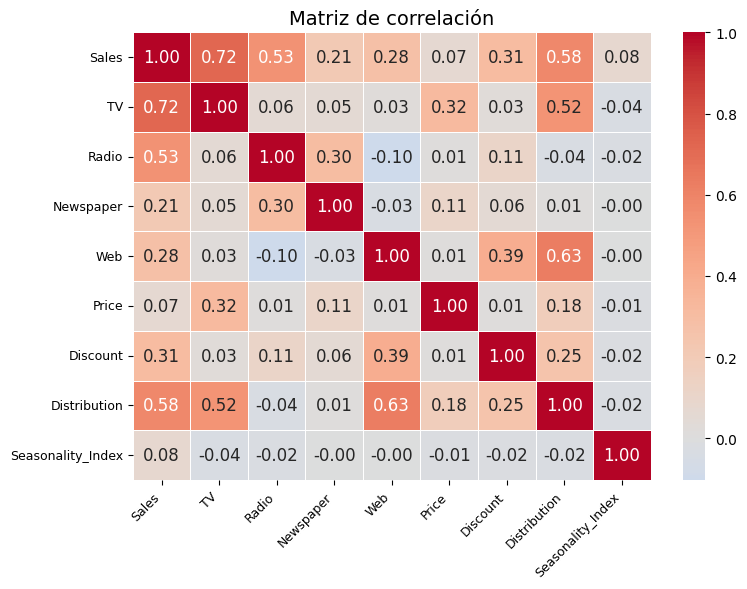

In [12]:
# diagrama de correlación
plt.figure(figsize=(8, 6))

# Mapa de correlación
sns.heatmap(ventas.corr(),                # matriz de correlaciones
            annot=True,                   # para colocar números adentro (correlaciones)
            fmt=".2f",                    # formato de los números
            cmap="coolwarm",              # colores frio-caliente
            center=0,                     # centro de la escala
            annot_kws={"size": 12},        # tamaño de los números
            linewidths=0.5
)

# Tamaño de etiquetas
plt.xticks(fontsize=9, rotation=45, ha="right")
plt.yticks(fontsize=9, rotation=0)

plt.title("Matriz de correlación", fontsize=14)

plt.tight_layout()
plt.show()

In [13]:
# diagrama de dispersión.
px.scatter(ventas,
           x="TV",
           y="Sales",
           trendline="ols")

In [15]:
px.scatter(ventas,
           x="Radio",
           y="Sales",
           trendline="ols")

## <FONT SIZE=4 COLOR="purple"> 5.3 Modelos de regresión  </FONT>

Primero definimos la función de evaluación de los modelos.

In [26]:
# función para evaluar modelos de regresión
def evaluar_modelo(modelo, nombre_modelo, X_train, X_test, y_train, y_test):
    # Predicciones
    y_pred_train = modelo.predict(X_train)
    y_pred_test = modelo.predict(X_test)

    # Métricas train
    r2_train = r2_score(y_train, y_pred_train)
    mse_train = mean_squared_error(y_train, y_pred_train)
    rmse_train = np.sqrt(mse_train)
    mae_train = mean_absolute_error(y_train, y_pred_train)

    # Métricas test
    r2_test = r2_score(y_test, y_pred_test)
    mse_test = mean_squared_error(y_test, y_pred_test)
    rmse_test = np.sqrt(mse_test)
    mae_test = mean_absolute_error(y_test, y_pred_test)

    # DataFrame
    df_metricas = pd.DataFrame(
        [
            [r2_train, mse_train, rmse_train, mae_train],
            [r2_test, mse_test, rmse_test, mae_test]
        ],
        index=[f"{nombre_modelo}_train", f"{nombre_modelo}_test"],
        columns=["r2", "mse", "rmse", "mae"]
    )

    return df_metricas

Ahora seleccionamos la variable objetivo y la variable predictora

In [27]:
# variable objetivo
y = ventas['Sales']
# variables predictoras
X = ventas.drop('Sales', axis=1)

# conjunto de entrenamiento y prueba
X_train,X_test,y_train,y_test=train_test_split(X,
                                               y,
                                               train_size=0.70,
                                               random_state=123)
# escalar los datos : para regresión lineal
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

### <FONT SIZE=4 COLOR="purple"> 5.3.1 Modelo de Regresión Lineal  </FONT>

In [28]:
# modelo de regresión lineal
modelo_linear = LinearRegression()
# entrenamiento
modelo_linear.fit(X_train_s,y_train)
# Evaluar el modelo
evaluacion_linear = evaluar_modelo(modelo_linear, "linear", X_train_s, X_test_s, y_train, y_test)
evaluacion_linear


,r2,mse,rmse,mae
linear_train,0.929131,1.911141,1.382440,1.093424
linear_test,0.923217,2.198508,1.482736,1.185141


In [21]:
# variable objetivo : sales ud.
y.describe()

,Sales
count,2000.000000
mean,14.723865
std,5.242777
min,1.500000
25%,10.907500
50%,14.310000
75%,18.240000
max,29.790000


In [29]:
1.09 / (27-1.6)

0.042913385826771656

Veamos los coeficientes

In [30]:
print(modelo_linear.intercept_)
print(modelo_linear.coef_)

14.672614285714282
[ 3.54718461  2.67157663  0.19500037  1.00663471 -0.97166811  0.61019247
  0.61482076  0.61955192]


Esto indica que:

$$
\begin{aligned}
\widehat{Sales} =\;&14.6726\\
&+3.5472(TV)\\
&+2.6716(Radio)\\
&+0.1950(Newspaper)\\
&+1.0066(Web)\\
&-0.9717(Price)\\
&+0.6102(Discount)\\
&+0.6148(Distribution)\\
&+0.6196(Seasonality\_Index)
\end{aligned}
$$


In [35]:

import numpy as np
import pandas as pd

# Nombres de las variables (mismo orden del entrenamiento)
variables = [
    'TV', 'Radio', 'Newspaper', 'Web',
    'Price', 'Discount', 'Distribution',
    'Seasonality_Index'
]

# Recuperar coeficientes en escala original
coef_originales = modelo_linear.coef_.ravel() / scaler.scale_

# Recuperar intercepto original
intercepto_original = (
    modelo_linear.intercept_
    - np.sum(coef_originales * scaler.mean_)
)

# Tabla de resultados
tabla = pd.DataFrame({
    'Variable': variables,
    'Coeficiente escalado': modelo_linear.coef_.ravel(),
    'Coeficiente original': coef_originales
})

display(tabla)

print(f"Intercepto original: {float(intercepto_original):.6f}")

# Mostrar ecuación completa
ecuacion = f"Sales = {float(intercepto_original):.6f}"

for variable, coef in zip(variables, coef_originales):
    ecuacion += f" {coef:+.6f}*{variable}"

print("\nEcuación en escala original:")
print(ecuacion)


,Variable,Coeficiente escalado,Coeficiente original
0,TV,3.547185,0.041552
1,Radio,2.671577,0.172451
2,Newspaper,0.195000,0.008968
3,Web,1.006635,0.012995
4,Price,-0.971668,-0.278544
5,Discount,0.610192,0.162488
6,Distribution,0.614821,0.053242
7,Seasonality_Index,0.619552,4.952011


Intercepto original: -1.907530

Ecuación en escala original:
Sales = -1.907530 +0.041552*TV +0.172451*Radio +0.008968*Newspaper +0.012995*Web -0.278544*Price +0.162488*Discount +0.053242*Distribution +4.952011*Seasonality_Index


**Interpretación de los coeficientes más relevantes**

| Variable | Coeficiente original | Interpretación |
|---|---:|---|
| TV | +0.041552 | Por cada unidad adicional invertida en publicidad televisiva, las ventas estimadas aumentan 0.0416 unidades. |
| Radio | +0.172451 | Por cada unidad adicional invertida en publicidad radial, las ventas estimadas aumentan 0.1725 unidades. |
| Price | -0.278544 | Por cada unidad que aumenta el precio del producto, las ventas estimadas disminuyen 0.2785 unidades. |
| Discount | +0.162488 | Por cada unidad adicional de descuento, las ventas estimadas aumentan 0.1625 unidades. |
| Seasonality_Index | +4.952011 | Un incremento de una unidad en el índice de estacionalidad se asocia con un aumento estimado de 4.952 unidades en ventas. |


### <FONT SIZE=4 COLOR="purple"> 5.3.2 Modelo de KNN </FONT>

In [36]:
# modelo (obligatorio escalar)
modelo_knn = KNeighborsRegressor(n_neighbors=5)
# entrenamiento
modelo_knn.fit(X_train_s, y_train)
# evaluar el modelo
evaluacion_knn = evaluar_modelo(modelo_knn, "knn", X_train_s, X_test_s, y_train, y_test)
evaluacion_knn

,r2,mse,rmse,mae
knn_train,0.898338,2.741533,1.655757,1.319546
knn_test,0.848755,4.330584,2.081006,1.658340


### <FONT SIZE=4 COLOR="purple"> 5.3.3 Modelo de Árboles de Decisión  </FONT>

In [37]:
# modelo (no es necesario escalar)
modelo_tree = DecisionTreeRegressor(random_state= 0)
# entrenamiento
modelo_tree.fit(X_train, y_train)
# evaluar el modelo
evaluacion_tree = evaluar_modelo(modelo_tree, "tree", X_train, X_test, y_train, y_test)
evaluacion_tree

,r2,mse,rmse,mae
tree_train,1.000000,0.000000,0.000000,0.000000
tree_test,0.749503,7.172448,2.678143,2.093883


### <FONT SIZE=4 COLOR="purple"> 5.3.4 Modelo de SVR  </FONT>

In [38]:
# modelo (importante escalar)
modelo_svr= SVR()
# entrenamiento
modelo_svr.fit(X_train_s, y_train)
# evaluar el modelo
evaluacion_svr = evaluar_modelo(modelo_svr,"svr", X_train_s, X_test_s, y_train, y_test)
evaluacion_svr

,r2,mse,rmse,mae
svr_train,0.914279,2.311635,1.520406,1.144458
svr_test,0.888617,3.189228,1.785841,1.381064


In [ ]:
evaluacion_linear = evaluar_modelo(modelo_linear, "linear", X_train_s, X_test_s, y_train, y_test)
evaluacion_linear

### <FONT SIZE=4 COLOR="purple"> 5.3.5 Modelo de Random Forest </FONT>



In [39]:
# modelo (no es necesario escalar)
modelo_rf = RandomForestRegressor(random_state=0)
# entrenamiento
modelo_rf.fit(X_train, y_train)
# evaluar el modelo
evaluacion_rf = evaluar_modelo(modelo_rf, "rf", X_train, X_test, y_train, y_test)
evaluacion_rf

,r2,mse,rmse,mae
rf_train,0.983424,0.447006,0.668585,0.527047
rf_test,0.890376,3.138845,1.771679,1.400523


Ahora una tabla resumen con todas las métricas

In [41]:
# dataframe con todas las métricas
df_modelos = pd.concat([evaluacion_linear,
                        evaluacion_knn,
                        evaluacion_tree,
                        evaluacion_svr,
                        evaluacion_rf])

df_modelos

,r2,mse,rmse,mae
linear_train,0.929131,1.911141,1.382440,1.093424
linear_test,0.923217,2.198508,1.482736,1.185141
knn_train,0.898338,2.741533,1.655757,1.319546
knn_test,0.848755,4.330584,2.081006,1.658340
tree_train,1.000000,0.000000,0.000000,0.000000
tree_test,0.749503,7.172448,2.678143,2.093883
svr_train,0.914279,2.311635,1.520406,1.144458
svr_test,0.888617,3.189228,1.785841,1.381064
rf_train,0.983424,0.447006,0.668585,0.527047
rf_test,0.890376,3.138845,1.771679,1.400523


In [42]:
display(df_modelos.iloc[[0,2,4,6,8]])
display(df_modelos.iloc[[1,3,5,7,9]])

,r2,mse,rmse,mae
linear_train,0.929131,1.911141,1.382440,1.093424
knn_train,0.898338,2.741533,1.655757,1.319546
tree_train,1.000000,0.000000,0.000000,0.000000
svr_train,0.914279,2.311635,1.520406,1.144458
rf_train,0.983424,0.447006,0.668585,0.527047


,r2,mse,rmse,mae
linear_test,0.923217,2.198508,1.482736,1.185141
knn_test,0.848755,4.330584,2.081006,1.658340
tree_test,0.749503,7.172448,2.678143,2.093883
svr_test,0.888617,3.189228,1.785841,1.381064
rf_test,0.890376,3.138845,1.771679,1.400523


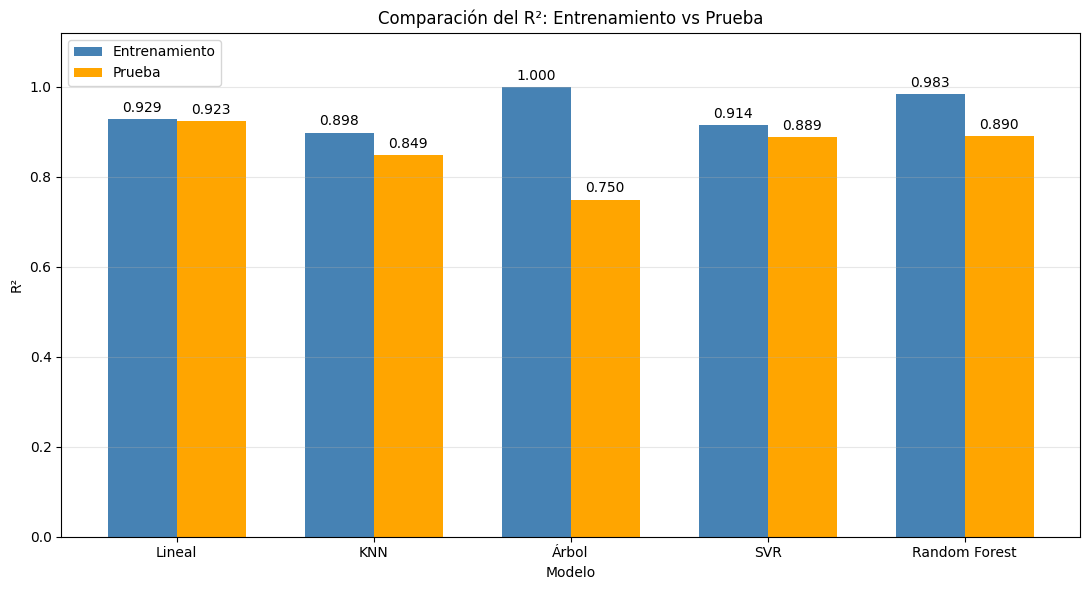

In [43]:
# gráficar las métricas
# Nombres de los modelos
modelos = ['Lineal', 'KNN', 'Árbol', 'SVR', 'Random Forest']

# Extraer R² directamente de df_modelos
r2_train = df_modelos.loc[
    ['linear_train', 'knn_train', 'tree_train', 'svr_train', 'rf_train'],
    'r2'
].values

r2_test = df_modelos.loc[
    ['linear_test', 'knn_test', 'tree_test', 'svr_test', 'rf_test'],
    'r2'
].values

# Posiciones de las barras
x = np.arange(len(modelos))
ancho = 0.35

# Crear gráfica
plt.figure(figsize=(11, 6))

barras1 = plt.bar(
    x - ancho/2, r2_train, ancho,
    label='Entrenamiento', color='steelblue'
)

barras2 = plt.bar(
    x + ancho/2, r2_test, ancho,
    label='Prueba', color='orange'
)

# Mostrar valores encima de cada barra
plt.bar_label(barras1, fmt='%.3f', padding=3)
plt.bar_label(barras2, fmt='%.3f', padding=3)

# Personalización
plt.xlabel('Modelo')
plt.ylabel('R²')
plt.title('Comparación del R²: Entrenamiento vs Prueba')
plt.xticks(x, modelos)
plt.ylim(0, 1.12)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


**Análisis de las métricas**

Recordemos que:

- $R^2$: cuanto más cercano a 1, mayor proporción de la variabilidad de las ventas explica el modelo.
- $RMSE$: penaliza especialmente los errores grandes. Cuanto menor, mejor.
- $MAE$: representa el error absoluto promedio de las predicciones, expresado en las mismas unidades de Sales.

1. Regresión lineal

- La regresión lineal presentó un comportamiento estable entre entrenamiento y prueba, con valores de $R^2$ de $0.9291$ y $0.9232$, respectivamente.

- La pequeña diferencia entre ambas métricas indica una buena capacidad de generalización.

- Esto sugiere que las relaciones entre las variables predictoras y las ventas pueden ser representadas adecuadamente mediante una combinación lineal.

- Además, demuestra que un modelo más complejo no necesariamente proporciona mejores resultados predictivos.

2. Árbol de decisión (Decision Tree)

- Los árboles de decisión tienen una alta capacidad para aprender relaciones no lineales y construir reglas específicas a partir de los datos.

- Sin embargo, cuando no se controla su profundidad, pueden generar particiones demasiado específicas y terminar aprendiendo particularidades de los datos de entrenamiento, incluyendo el ruido.

- Este comportamiento se conoce como **sobreajuste (overfitting)**.

- En los resultados obtenidos, el árbol alcanzó un $R^2$ de $1.00$ en entrenamiento, pero disminuyó a $0.7495$ en prueba.

- Esto evidencia que el modelo aprendió excesivamente los datos de entrenamiento y presentó dificultades para generalizar ante observaciones nuevas.

- Para reducir este problema pueden utilizarse técnicas de regularización como:

- Limitar la profundidad del árbol (`max_depth`).
- Establecer un número mínimo de muestras por hoja (`min_samples_leaf`).
- Controlar el número mínimo de muestras para realizar divisiones (`min_samples_split`).

3. Random Forest

- Random Forest combina múltiples árboles de decisión para generar una predicción conjunta.

- Esta estrategia permite reducir la varianza y disminuir el riesgo de sobreajuste respecto a un árbol individual.

- En este ejercicio, Random Forest obtuvo un $R^2$ de $0.9834$ en entrenamiento y $0.8904$ en prueba.

- Aunque presenta cierta diferencia entre ambos conjuntos, su capacidad de generalización fue superior a la del árbol individual.

- Esto demuestra cómo los métodos de ensamble pueden mejorar la estabilidad de modelos que individualmente presentan una alta varianza.

Sin embargo, Random Forest no elimina completamente el riesgo de sobreajuste.

4. K-Nearest Neighbors (KNN)

- KNN realiza predicciones a partir de las observaciones más cercanas a un nuevo registro.

- Su comportamiento depende especialmente del número de vecinos (`n_neighbors`) y de la escala de las variables.

- Un valor de K demasiado pequeño puede producir sobreajuste, mientras que uno demasiado grande puede generar subajuste.

- En este caso, KNN obtuvo un $R^2$ de $0.8983$ en entrenamiento y $0.8488$ en prueba.

- Aunque presenta una diferencia moderada entre ambos conjuntos, su desempeño predictivo fue inferior al de la regresión lineal.

5. Support Vector Regression (SVR)

- SVR busca construir una función de regresión que mantenga los errores dentro de un margen de tolerancia, controlando al mismo tiempo la complejidad del modelo.

- Su comportamiento depende de parámetros como `C`, `epsilon` y `gamma`, este último cuando se utilizan kernels como RBF.

- En los resultados obtenidos, SVR alcanzó un $R^2$ de $0.9143$ en entrenamiento y $0.8886$ en prueba.

- La diferencia relativamente pequeña entre ambos resultados sugiere una capacidad de generalización estable.

- No obstante, su rendimiento fue inferior al de la regresión lineal en este conjunto de datos.

**Conclusión general**

- Los resultados muestran que los modelos de mayor complejidad no necesariamente presentan una mayor capacidad predictiva.

- El árbol de decisión evidenció un comportamiento característico de sobreajuste, mientras que Random Forest logró reducir este problema mediante la combinación de múltiples árboles.

- Por su parte, KNN y SVR presentaron resultados relativamente estables, aunque inferiores a los obtenidos mediante regresión lineal.

- La regresión lineal presentó el mejor desempeño en los datos de prueba, con un $R^2$ de 0.9232 y los menores errores de predicción.

Esto sugiere que, para este conjunto de datos, un modelo lineal puede representar adecuadamente gran parte de la relación entre las variables comerciales y las ventas.

Podemos ver la importancia de las variables

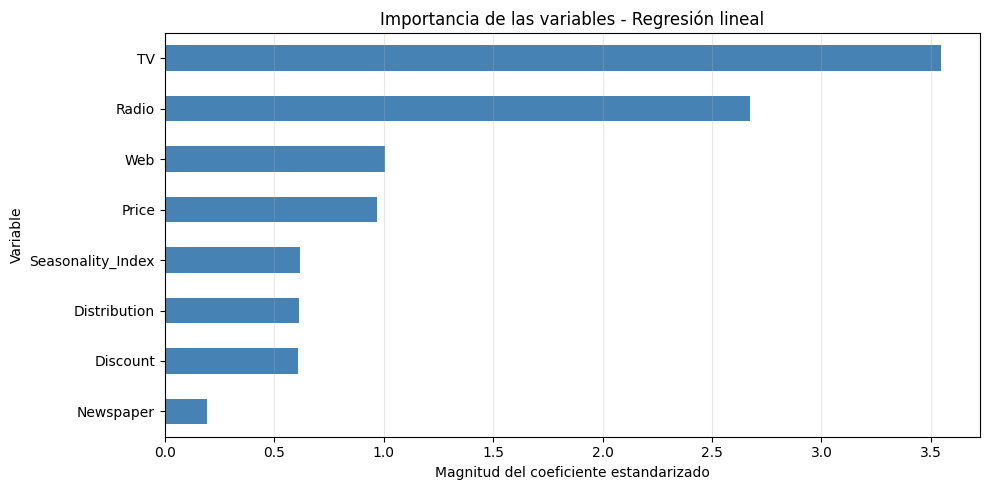

In [44]:
# importancia de las variables para regresión
# Importancia de las variables
importancias_lineal = pd.Series(
    np.abs(modelo_linear.coef_),
    index=X_train.columns
).sort_values(ascending=True)

# Gráfica
plt.figure(figsize=(10, 5))

importancias_lineal.plot(
    kind='barh',
    color='steelblue'
)

plt.xlabel('Magnitud del coeficiente estandarizado')
plt.ylabel('Variable')
plt.title('Importancia de las variables - Regresión lineal')
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# importancia de las variable en árboles de decisión
modelo_rf.feature_importances_
importancias = pd.Series(modelo_rf.feature_importances_,
                         index=X_train.columns
                         ).sort_values(ascending=False)
importancias

## <FONT SIZE=4 COLOR="purple"> 5.4 Análisis de los resultados de regresión en test  </FONT>

In [45]:
# Predicciones de regresión lineal en TEST

# 1. Realizar predicciones con los datos escalados
y_pred_linear = modelo_linear.predict(X_test_s)

# 2. Recuperar las variables originales del conjunto test
df_predicciones = X_test.copy()

# 3. Agregar los valores reales y predichos
df_predicciones['Sales_Real'] = y_test
df_predicciones['Sales_Predicho'] = y_pred_linear

# 4. Calcular los errores
df_predicciones['Error'] = (
    df_predicciones['Sales_Real']
    - df_predicciones['Sales_Predicho']
)

df_predicciones['Error_Absoluto'] = (
    df_predicciones['Error'].abs()
)

df_predicciones['Error_Cuadratico'] = (
    df_predicciones['Error'] ** 2
)

# 5. Organizar y visualizar resultados
display(df_predicciones.round(2))


,TV,Radio,Newspaper,Web,Price,Discount,Distribution,Seasonality_Index,Sales_Real,Sales_Predicho,Error,Error_Absoluto,Error_Cuadratico
1342,159.40,48.89,59.41,253.49,20.30,5.98,74.65,1.01,20.93,21.27,-0.34,0.34,0.11
1338,119.39,11.14,43.16,50.65,18.90,4.67,55.34,0.92,9.17,9.02,0.15,0.15,0.02
189,206.72,11.77,22.31,208.21,21.52,8.54,62.28,0.83,16.09,14.44,1.65,1.65,2.73
1332,277.08,34.21,56.98,216.80,22.85,12.65,83.44,1.00,25.15,23.92,1.23,1.23,1.52
1816,178.76,41.72,5.64,206.52,22.18,6.14,61.15,0.86,15.77,17.78,-2.01,2.01,4.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...
457,132.08,21.18,17.09,274.57,18.08,11.11,76.41,1.16,17.82,17.54,0.28,0.28,0.08
1126,242.58,29.31,12.90,130.28,19.36,4.66,67.73,1.07,18.57,19.30,-0.73,0.73,0.54
820,66.64,13.37,28.97,228.38,21.71,9.87,52.29,1.28,8.51,11.07,-2.56,2.56,6.57
1552,79.23,14.55,39.90,219.45,28.32,7.80,69.68,0.92,10.24,8.75,1.49,1.49,2.23


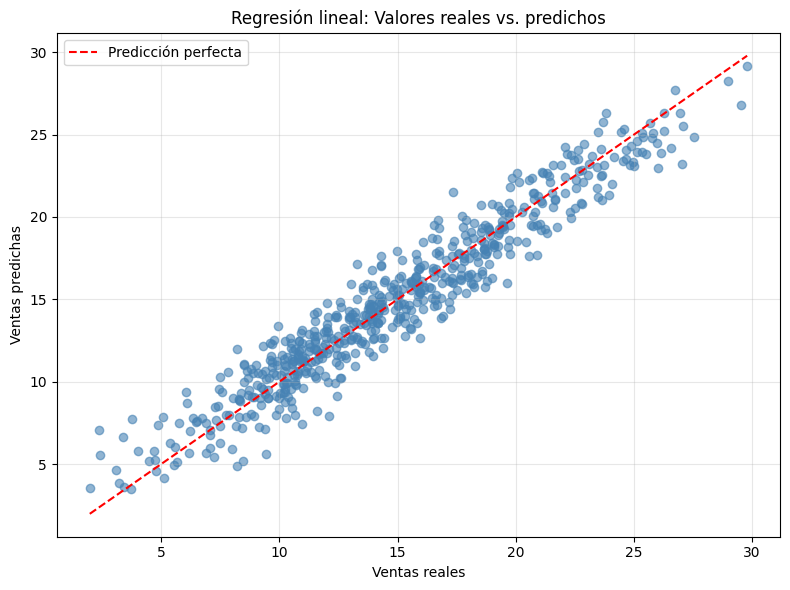

In [47]:
# gráfica de valores reales vs predicción

plt.figure(figsize=(8, 6))

# Valores reales frente a predicciones
plt.scatter(
    df_predicciones['Sales_Real'],
    df_predicciones['Sales_Predicho'],
    alpha=0.6,
    color='steelblue'
)

# Línea de predicción perfecta
minimo = min(
    df_predicciones['Sales_Real'].min(),
    df_predicciones['Sales_Predicho'].min()
)

maximo = max(
    df_predicciones['Sales_Real'].max(),
    df_predicciones['Sales_Predicho'].max()
)

plt.plot(
    [minimo, maximo],
    [minimo, maximo],
    'r--',
    label='Predicción perfecta'
)

plt.xlabel('Ventas reales')
plt.ylabel('Ventas predichas')
plt.title('Regresión lineal: Valores reales vs. predichos')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## <FONT SIZE=4 COLOR="purple"> 5.5 Validación Cruzada y Búsqueda en Grilla  </FONT>

**Validación Cruzada**

In [48]:

from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline        import Pipeline


# Pipeline: escalamiento + regresión lineal
pipeline_linear = Pipeline([
    ('scaler', StandardScaler()),
    ('modelo', LinearRegression())
])

# Validación cruzada de 5 particiones
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=123
)

# Métricas de evaluación
metricas = {
    'R2': 'r2',
    'MAE': 'neg_mean_absolute_error',
    'MSE': 'neg_mean_squared_error'
}

# Ejecutar validación cruzada
resultados_cv = cross_validate(pipeline_linear,
                               X_train,
                               y_train,
                               cv=cv,
                               scoring=metricas,
                               return_train_score=True)

# Crear tabla de resultados
df_cv = pd.DataFrame({
    'Fold': range(1, 6),
    'R2_train': resultados_cv['train_R2'],
    'R2_validacion': resultados_cv['test_R2'],
    'MAE_validacion': -resultados_cv['test_MAE'],
    'MSE_validacion': -resultados_cv['test_MSE'],
    'RMSE_validacion': np.sqrt(
        -resultados_cv['test_MSE']
    )
})

display(df_cv.round(4))

# Resumen
print("\nPROMEDIO DE VALIDACIÓN CRUZADA")
print(df_cv.mean().round(4))

print("\nDESVIACIÓN ESTÁNDAR")
print(df_cv.std().round(4))


,Fold,R2_train,R2_validacion,MAE_validacion,MSE_validacion,RMSE_validacion
0,1,0.9289,0.9295,1.1060,1.9892,1.4104
1,2,0.9291,0.9289,1.0755,1.7771,1.3331
2,3,0.9299,0.9256,1.1247,1.9938,1.4120
3,4,0.9264,0.9386,1.0246,1.7128,1.3088
4,5,0.9319,0.9177,1.1621,2.1977,1.4825



PROMEDIO DE VALIDACIÓN CRUZADA
Fold               3.0000
R2_train           0.9292
R2_validacion      0.9281
MAE_validacion     1.0986
MSE_validacion     1.9341
RMSE_validacion    1.3893
dtype: float64

DESVIACIÓN ESTÁNDAR
Fold               1.5811
R2_train           0.0020
R2_validacion      0.0075
MAE_validacion     0.0519
MSE_validacion     0.1934
RMSE_validacion    0.0694
dtype: float64


**Búsqueda en grilla**

In [49]:

from sklearn.linear_model     import Ridge, Lasso
from sklearn.model_selection  import GridSearchCV
from sklearn.pipeline         import Pipeline

# Pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('modelo', Ridge())
])

# Hiperparámetros
param_grid = [
    {
        'modelo': [Ridge()],
        'modelo__alpha': [0.01, 0.1, 1, 10, 100]
    },
    {
        'modelo': [Lasso(max_iter=10000)],
        'modelo__alpha': [0.001, 0.01, 0.1, 1, 10]
    }
]

# GridSearchCV
grid_regularizacion = GridSearchCV(estimator=pipeline,
                                   param_grid=param_grid,
                                   scoring='r2',
                                   cv=cv,
                                   return_train_score=True)

# Entrenar
grid_regularizacion.fit(X_train, y_train)

print("Mejor modelo:")
print(grid_regularizacion.best_estimator_)

print("\nMejores parámetros:")
print(grid_regularizacion.best_params_)

print("\nMejor R² promedio:")
print(round(grid_regularizacion.best_score_, 4))

# Tabla de resultados
df_regularizacion = pd.DataFrame(
    grid_regularizacion.cv_results_
)

display(
    df_regularizacion[
        [
            'param_modelo',
            'param_modelo__alpha',
            'mean_train_score',
            'mean_test_score',
            'std_test_score',
            'rank_test_score'
        ]
    ].sort_values('rank_test_score')
)


Mejor modelo:
Pipeline(steps=[('scaler', StandardScaler()), ('modelo', Ridge(alpha=1))])

Mejores parámetros:
{'modelo': Ridge(), 'modelo__alpha': 1}

Mejor R² promedio:
0.9281


,param_modelo,param_modelo__alpha,mean_train_score,mean_test_score,std_test_score,rank_test_score
2,Ridge(),1.000,0.929211,0.928086,0.006743,1
1,Ridge(),0.100,0.929212,0.928085,0.006749,2
0,Ridge(),0.010,0.929212,0.928085,0.006749,3
5,Lasso(max_iter=10000),0.001,0.929212,0.928085,0.006755,4
6,Lasso(max_iter=10000),0.010,0.929186,0.928058,0.006793,5
3,Ridge(),10.000,0.929114,0.928006,0.006695,6
7,Lasso(max_iter=10000),0.100,0.926639,0.925463,0.007241,7
4,Ridge(),100.000,0.922378,0.921312,0.006853,8
8,Lasso(max_iter=10000),1.000,0.758451,0.756626,0.016539,9
9,Lasso(max_iter=10000),10.000,0.000000,-0.001994,0.002185,10


In [50]:
# evaluamos el mejor modelo
from sklearn.metrics import (r2_score,
                             mean_absolute_error,
                             mean_squared_error)

# Recuperar el mejor modelo
mejor_modelo = grid_regularizacion.best_estimator_

# Predicción en TEST
# El Pipeline realiza automáticamente el escalamiento
y_pred = mejor_modelo.predict(X_test)

# Métricas
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("EVALUACIÓN FINAL")
print("---------------------------")
print(f"R²:   {r2:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")


EVALUACIÓN FINAL
---------------------------
R²:   0.9232
MAE:  1.1849
MSE:  2.1977
RMSE: 1.4825


## <FONT SIZE=4 COLOR="purple"> 5.6 Predicciones </FONT>

In [51]:
# Cargar los 50 registros nuevos
df_nuevos = pd.read_csv("https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/Regresion/Datos/ventas_50_nuevos_prediccion.csv",
                        sep=';',
                        decimal=',' )

# Aplicar el mismo escalador del entrenamiento
X_nuevos_s = scaler.transform(df_nuevos)

# Realizar predicciones
df_nuevos['Sales_Predicho'] = modelo_linear.predict(X_nuevos_s)

# Visualizar resultados
display(df_nuevos.round(2))





,TV,Radio,Newspaper,Web,Price,Discount,Distribution,Seasonality_Index,Sales_Predicho
0,178.90,47.06,5.68,222.76,11.58,4.62,68.65,1.04,22.92
1,70.80,6.61,7.05,250.44,21.74,5.53,60.22,0.99,8.44
2,99.92,0.54,25.28,195.08,18.81,14.40,57.53,1.14,10.91
3,245.29,27.02,26.50,152.77,20.80,5.80,52.95,1.19,19.03
4,101.91,31.97,46.19,213.42,17.66,9.71,65.18,1.21,17.15
5,220.27,27.07,3.19,189.40,19.66,1.88,60.78,1.04,17.62
6,146.54,12.23,10.69,51.61,17.98,9.87,69.34,1.11,12.84
7,294.85,25.84,0.30,192.75,23.53,16.71,76.86,1.11,23.06
8,0.70,38.52,50.68,224.74,19.52,6.55,50.02,0.78,10.29
9,124.26,49.57,52.91,144.42,16.71,10.33,50.60,0.93,18.48
